# RTU 전력 데이터 EDA
### 목적: 피처 엔지니어링 근거 확보 + 이상탐지 필요성 확인

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows면 'Malgun Gothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 & 기본 확인

In [2]:
# ⚠️ 파일 경로 본인 환경에 맞게 수정
df = pd.read_csv('rtu_data_full.csv')

print('shape:', df.shape)
print('컬럼:', df.columns.tolist())
print('\n기본 정보:')
df.info()

shape: (33696013, 19)
컬럼: ['module(equipment)', 'timestamp', 'localtime', 'operation', 'voltageR', 'voltageS', 'voltageT', 'voltageRS', 'voltageST', 'voltageTR', 'currentR', 'currentS', 'currentT', 'activePower', 'powerFactorR', 'powerFactorS', 'powerFactorT', 'reactivePowerLagging', 'accumActiveEnergy']

기본 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33696013 entries, 0 to 33696012
Data columns (total 19 columns):
 #   Column                Dtype  
---  ------                -----  
 0   module(equipment)     object 
 1   timestamp             int64  
 2   localtime             int64  
 3   operation             int64  
 4   voltageR              float64
 5   voltageS              float64
 6   voltageT              float64
 7   voltageRS             float64
 8   voltageST             float64
 9   voltageTR             float64
 10  currentR              float64
 11  currentS              float64
 12  currentT              float64
 13  activePower           float64
 14  powerF

In [3]:
df.head()

,module(equipment),timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
0,1(PM-3),1733040000000,20241201000000,1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,87.31,99.71,89.45,785.37,1955004
1,1(PM-3),1733040005000,20241201000005,1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,87.54,87.67,94.17,376.57,1955008
2,1(PM-3),1733040010000,20241201000010,1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,85.46,99.00,94.45,296.08,1955011
3,1(PM-3),1733040015000,20241201000015,1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,85.24,99.53,95.61,488.48,1955016
4,1(PM-3),1733040020000,20241201000020,1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,92.81,91.26,91.82,604.70,1955020


In [4]:
# 시간 변환
df['dt'] = pd.to_datetime(df['localtime'], format='%Y%m%d%H%M%S')
df['hour'] = df['dt'].dt.hour
df['dow'] = df['dt'].dt.dayofweek   # 0=월요일
df['date'] = df['dt'].dt.date
df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
df['month'] = df['dt'].dt.month

print('시간 범위:', df['dt'].min(), '~', df['dt'].max())
print('모듈 종류:', df['module(equipment)'].unique())
print('모듈 수:', df['module(equipment)'].nunique())

시간 범위: 2024-12-01 00:00:00 ~ 2025-04-30 00:00:00
모듈 종류: ['1(PM-3)' '2(L-1전등)' '3(분쇄기(2))' '4(분쇄기(1))' '5(좌측분전반)' '11(우측분전반1)'
 '12(4호기)' '13(3호기)' '14(2호기)' '15(예비건조기)' '16(호이스트)' '17(6호기)'
 '18(우측분전반2)']
모듈 수: 13


In [5]:
# 결측치 확인
print('결측치:')
print(df.isnull().sum())

# operation 분포
print('\noperation 분포:')
print(df['operation'].value_counts())

# activePower 기초통계
print('\nactivePower 기초통계:')
print(df['activePower'].describe())

결측치:
module(equipment)       0
timestamp               0
localtime               0
operation               0
voltageR                0
voltageS                0
voltageT                0
voltageRS               0
voltageST               0
voltageTR               0
currentR                0
currentS                0
currentT                0
activePower             0
powerFactorR            0
powerFactorS            0
powerFactorT            0
reactivePowerLagging    0
accumActiveEnergy       0
dt                      0
hour                    0
dow                     0
date                    0
is_weekend              0
month                   0
dtype: int64

operation 분포:
operation
1    33696013
Name: count, dtype: int64

activePower 기초통계:
count    3.369601e+07
mean     3.009952e+03
std      7.171454e+02
min      8.644400e+02
25%      2.503820e+03
50%      3.009850e+03
75%      3.515890e+03
max      5.220930e+03
Name: activePower, dtype: float64


In [ ]:
print('operation 분포:', df['operation'].value_counts().to_dict())

# 인사이트
# operation=0 & activePower>0 이상탐지 룰은 사용 불가 (operation 변수 자체가 의미 없음)
# 공장이 24시간 풀가동 중이거나, 센서가 항상 1로 찍히는 거거나. operation은 걍 빼도될듯.



operation 분포: {1: 33696013}


## 2. hourly_pow 생성
> **설비별 activePower → 1시간 평균 → 전체 합산**

In [ ]:
# 설비별 1시간 평균
df_hourly_module = (
    df.groupby(['module(equipment)', pd.Grouper(key='dt', freq='1H')])
    ['activePower'].mean()
    .reset_index()
)

# 전체 설비 합산 → hourly_pow
hourly_pow = (
    df_hourly_module.groupby('dt')['activePower']
    .sum()
    .reset_index()
    .rename(columns={'activePower': 'hourly_pow'})
)

print('hourly_pow shape:', hourly_pow.shape)
print(hourly_pow.head(10))

# 3,601시간치 데이터 (5개월)
# hourly_pow 범위 약 39,000kW대 — 13개 설비 합산이니까 맞아요
# 시간별로 큰 변동 없이 안정적으로 보임 > 스파이크 구간 잘 잡아내야함


hourly_pow shape: (3601, 2)
                   dt    hourly_pow
0 2024-12-01 00:00:00  39222.026694
1 2024-12-01 01:00:00  39229.376486
2 2024-12-01 02:00:00  38934.010514
3 2024-12-01 03:00:00  39066.889514
4 2024-12-01 04:00:00  39149.150819
5 2024-12-01 05:00:00  39040.463042
6 2024-12-01 06:00:00  39231.676347
7 2024-12-01 07:00:00  39138.645917
8 2024-12-01 08:00:00  39105.197611
9 2024-12-01 09:00:00  39147.786250


In [21]:
print(hourly_pow.head(10))

                   dt    hourly_pow  hour  dow  is_weekend
0 2024-12-01 00:00:00  39222.026694     0    6           1
1 2024-12-01 01:00:00  39229.376486     1    6           1
2 2024-12-01 02:00:00  38934.010514     2    6           1
3 2024-12-01 03:00:00  39066.889514     3    6           1
4 2024-12-01 04:00:00  39149.150819     4    6           1
5 2024-12-01 05:00:00  39040.463042     5    6           1
6 2024-12-01 06:00:00  39231.676347     6    6           1
7 2024-12-01 07:00:00  39138.645917     7    6           1
8 2024-12-01 08:00:00  39105.197611     8    6           1
9 2024-12-01 09:00:00  39147.786250     9    6           1


## 3. 시간 패턴 EDA
> **목적: hour_sin/cos, dow_sin/cos, is_weekend 피처 근거 확보**

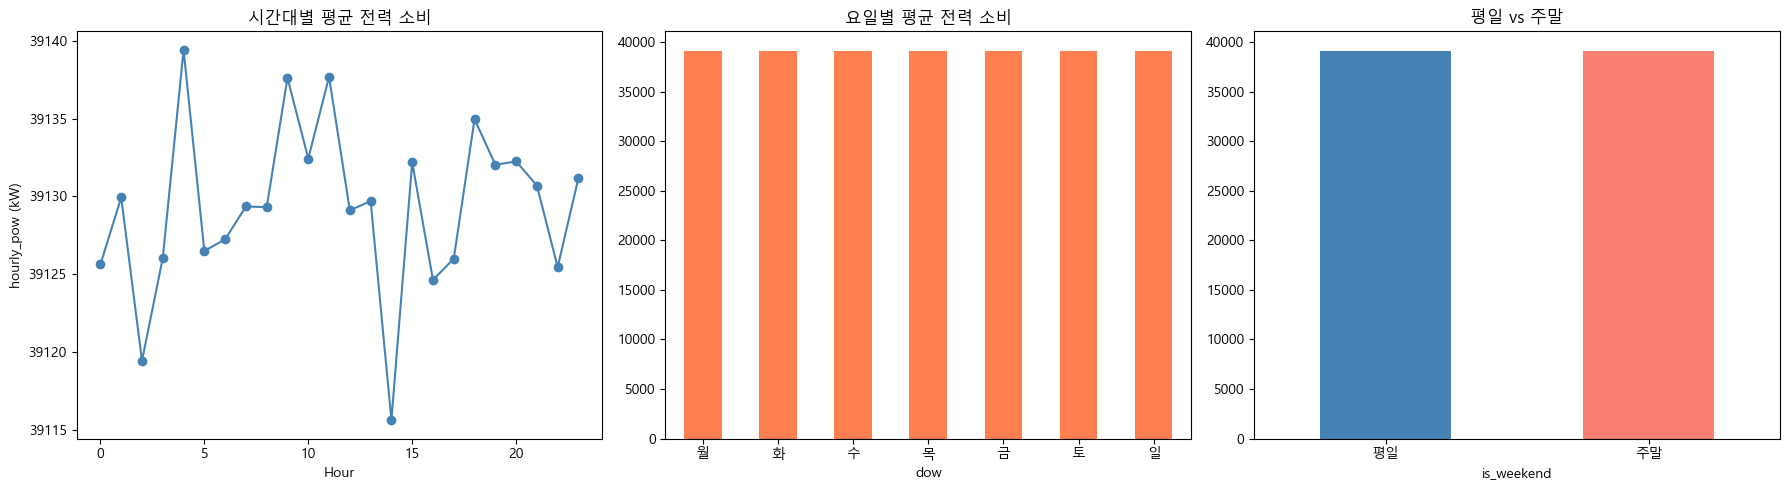

→ 인사이트: 시간대/요일별 패턴이 뚜렷하면 sin/cos 피처 정당화


In [ ]:
hourly_pow['hour'] = hourly_pow['dt'].dt.hour
hourly_pow['dow'] = hourly_pow['dt'].dt.dayofweek
hourly_pow['is_weekend'] = hourly_pow['dow'].isin([5,6]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 시간대별 평균
hourly_pow.groupby('hour')['hourly_pow'].mean().plot(
    ax=axes[0], marker='o', color='steelblue'
)
axes[0].set_title('시간대별 평균 전력 소비')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('hourly_pow (kW)')

# 요일별 평균
dow_labels = ['월','화','수','목','금','토','일']
hourly_pow.groupby('dow')['hourly_pow'].mean().plot(
    ax=axes[1], kind='bar', color='coral'
)
axes[1].set_title('요일별 평균 전력 소비')
axes[1].set_xticklabels(dow_labels, rotation=0)

# 주말/평일
hourly_pow.groupby('is_weekend')['hourly_pow'].mean().plot(
    ax=axes[2], kind='bar', color=['steelblue','salmon']
)
axes[2].set_title('평일 vs 주말')
axes[2].set_xticklabels(['평일','주말'], rotation=0)

plt.tight_layout()
plt.savefig('eda_01_time_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ 인사이트: 시간대/요일별 패턴이 뚜렷하면 sin/cos 피처 정당화')

# 요일별, 평일/주말은 걍 차이 없음 > dow, is_weekend 피처 걍 빼도 될듯
# 시간대별 변동폭도 해봐야 25kw(전체 39000 대비 0.06% 수준) > 설비별로 한번 더 쪼개봐야할듯


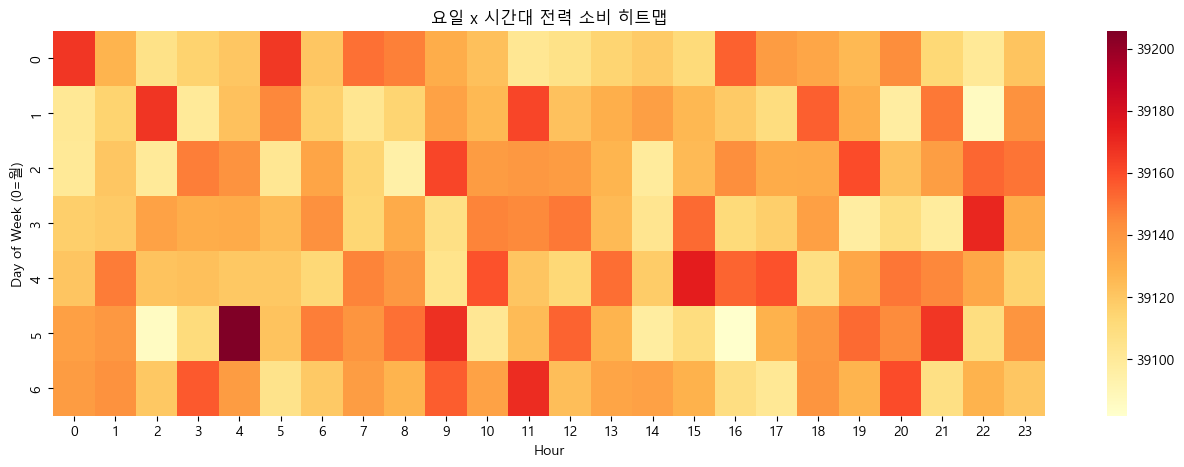

→ 인사이트: 피크 시간대와 요일 패턴 확인


In [13]:
# 요일 x 시간 히트맵
pivot = hourly_pow.pivot_table(values='hourly_pow', index='dow', columns='hour', aggfunc='mean')

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title('요일 x 시간대 전력 소비 히트맵')
plt.xlabel('Hour')
plt.ylabel('Day of Week (0=월)')
plt.savefig('eda_02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ 인사이트: 피크 시간대와 요일 패턴 확인')

## 4. 자기상관 분석 (ACF/PACF)
> **목적: lag1, lag24, lag168 피처 근거 확보**

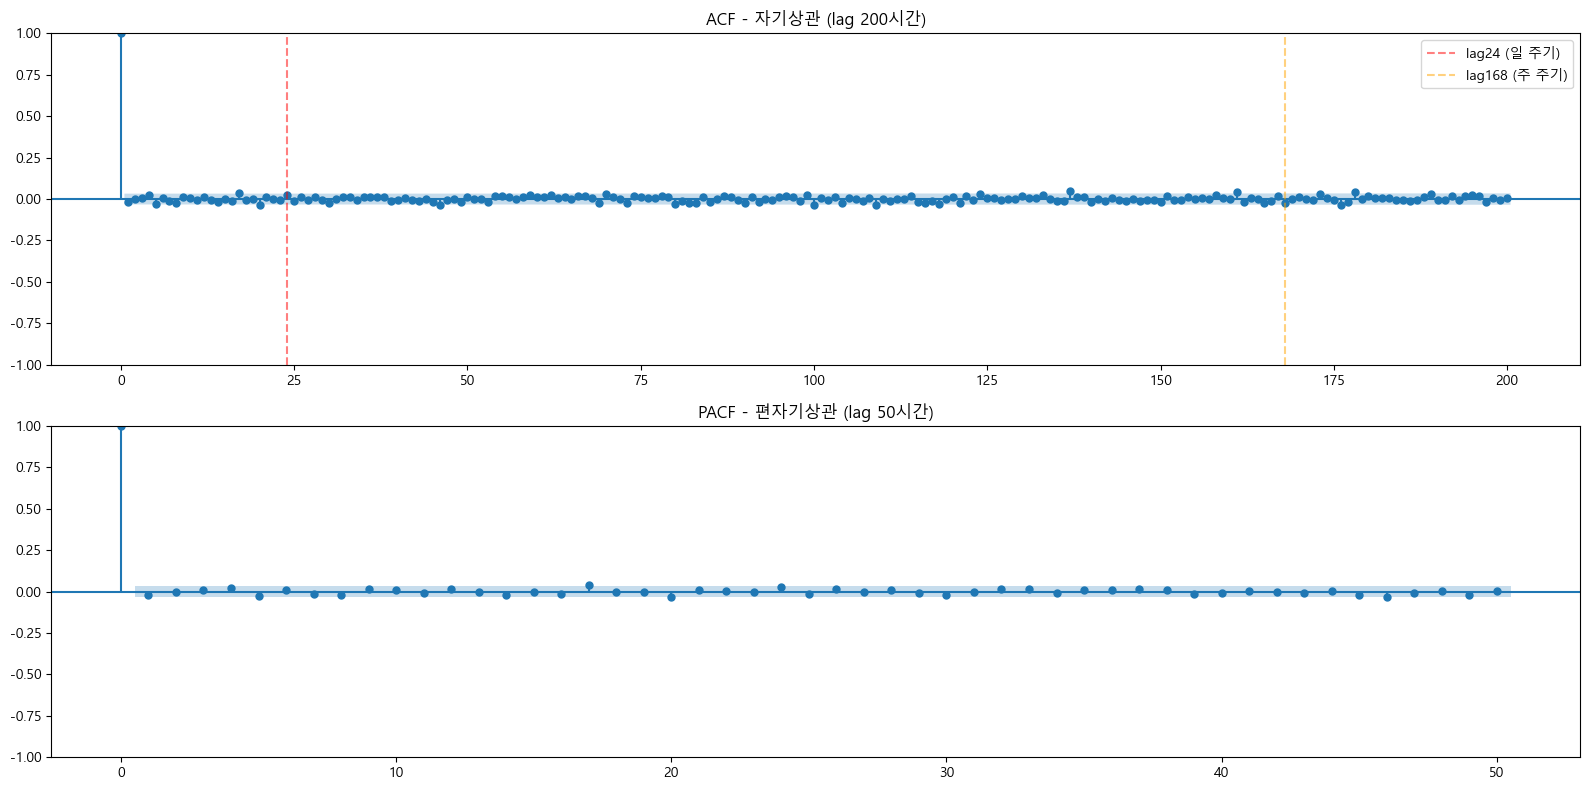

→ 인사이트: lag24/168에서 피크 → 일/주 주기성 존재 → lag 피처 정당화


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(hourly_pow['hourly_pow'].dropna(), lags=200, ax=axes[0])
axes[0].set_title('ACF - 자기상관 (lag 200시간)')
axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.5, label='lag24 (일 주기)')
axes[0].axvline(x=168, color='orange', linestyle='--', alpha=0.5, label='lag168 (주 주기)')
axes[0].legend()

plot_pacf(hourly_pow['hourly_pow'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('PACF - 편자기상관 (lag 50시간)')

plt.tight_layout()
plt.savefig('eda_03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ 인사이트: lag24/168에서 피크 → 일/주 주기성 존재 → lag 피처 정당화')

## 5. 설비별 패턴 비교
> **목적: Bottom-Up 예측 방식 정당화**

설비별 activePower 통계:
                          mean         std     min      max
module(equipment)                                          
4(분쇄기(1))          3010.729388  717.039418  873.63  5207.16
1(PM-3)            3010.413633  716.716297  880.88  5184.14
15(예비건조기)          3010.408632  717.035831  878.11  5213.06
5(좌측분전반)           3010.259966  717.742185  864.44  5175.69
18(우측분전반2)         3010.046483  717.124029  873.62  5195.08
12(4호기)            3010.032707  717.540003  874.71  5209.82
17(6호기)            3009.942371  716.942727  872.88  5184.32
2(L-1전등)           3009.914799  717.343771  873.87  5188.85
11(우측분전반1)         3009.911702  717.175406  878.54  5220.93
16(호이스트)           3009.765152  717.411093  882.67  5192.98
14(2호기)            3009.700472  716.963084  871.28  5193.97
3(분쇄기(2))          3009.570051  716.899373  870.97  5171.16
13(3호기)            3008.683028  716.955980  868.43  5219.73


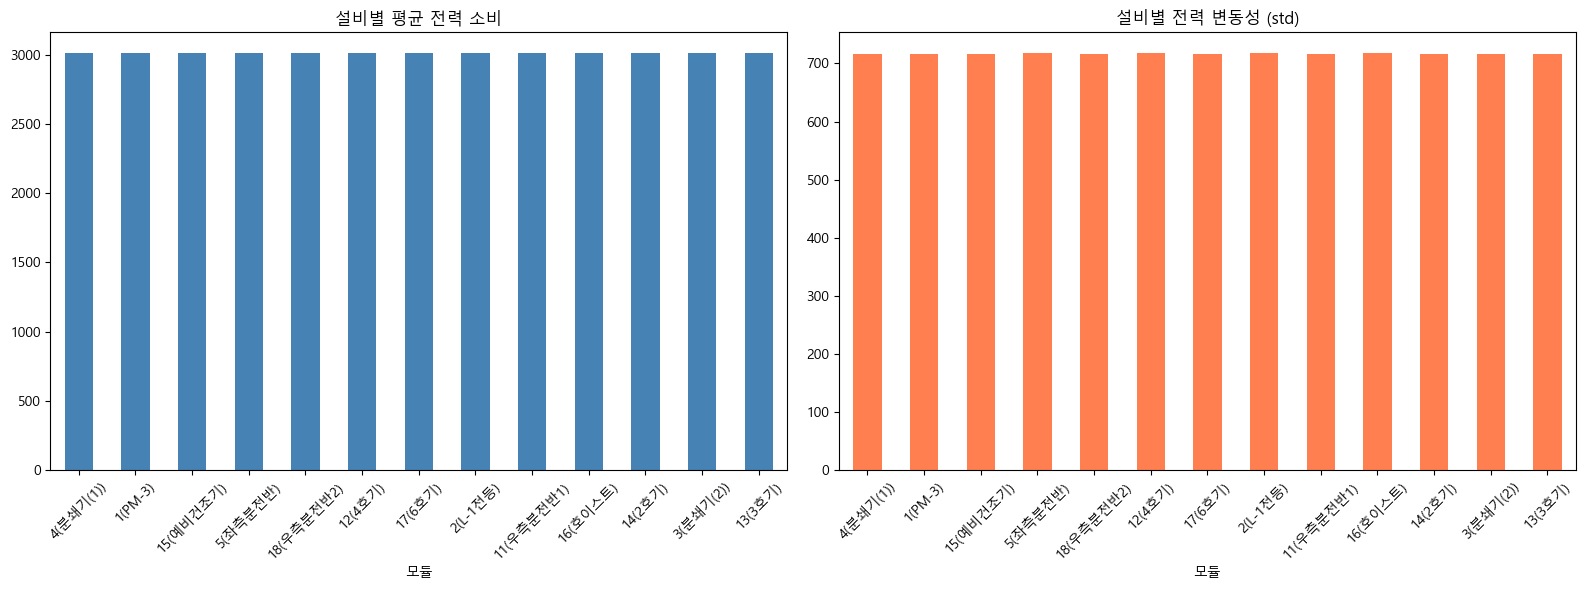

→ 인사이트: 설비별 소비 패턴이 다르면 Bottom-Up 방식 정당화


In [15]:
module_stats = (
    df.groupby('module(equipment)')['activePower']
    .agg(['mean','std','min','max'])
    .sort_values('mean', ascending=False)
)
print('설비별 activePower 통계:')
print(module_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

module_stats['mean'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('설비별 평균 전력 소비')
axes[0].set_xlabel('모듈')
axes[0].tick_params(axis='x', rotation=45)

module_stats['std'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('설비별 전력 변동성 (std)')
axes[1].set_xlabel('모듈')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_04_module_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ 인사이트: 설비별 소비 패턴이 다르면 Bottom-Up 방식 정당화')

## 6. 이상치 탐색
> **목적: 이상탐지 모델 필요성 근거 확보**

In [16]:
# Case 1: operation=0인데 activePower > 0 (가동 안 하는데 전력 소비)
anomaly_op = df[(df['operation'] == 0) & (df['activePower'] > 0)]
print(f'operation=0이지만 activePower>0인 케이스: {len(anomaly_op)}건')
print(anomaly_op[['module(equipment)','dt','activePower','operation']].head(10))

operation=0이지만 activePower>0인 케이스: 0건
Empty DataFrame
Columns: [module(equipment), dt, activePower, operation]
Index: []


설비별 IQR 이상치 건수:
module(equipment)
1(PM-3)       0
11(우측분전반1)    0
12(4호기)       0
13(3호기)       0
14(2호기)       0
15(예비건조기)     0
16(호이스트)      0
17(6호기)       0
18(우측분전반2)    0
2(L-1전등)      0
3(분쇄기(2))     0
4(분쇄기(1))     0
5(좌측분전반)      0
Name: is_outlier, dtype: int64


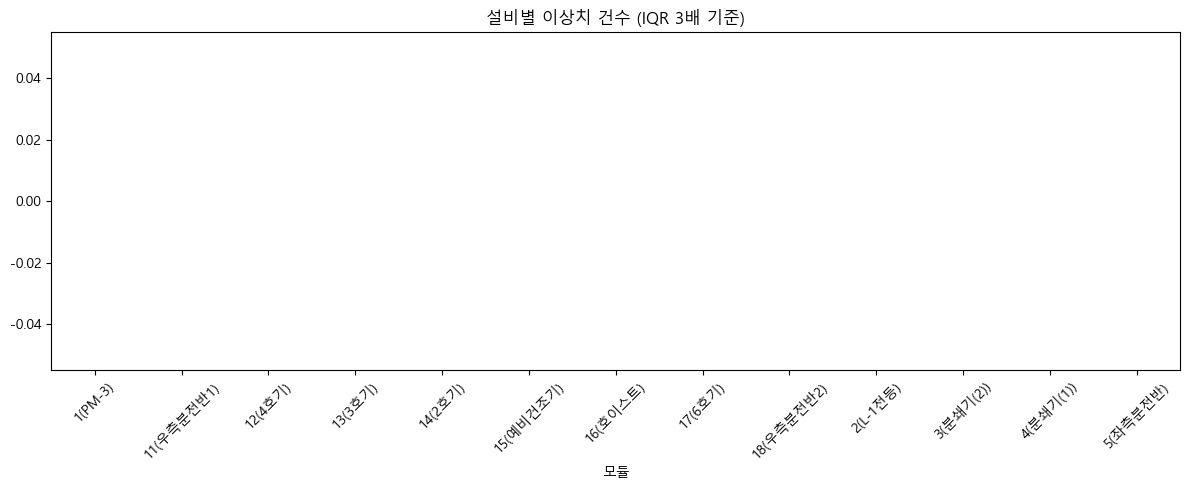

→ 인사이트: 이상치 많은 설비 = 이상탐지 모델 우선 적용 대상


In [17]:
# Case 2: 설비별 IQR 기반 이상치
def detect_iqr_outlier(group):
    Q1 = group['activePower'].quantile(0.25)
    Q3 = group['activePower'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    group['is_outlier'] = ~group['activePower'].between(lower, upper)
    return group

df = df.groupby('module(equipment)', group_keys=False).apply(detect_iqr_outlier)

outlier_count = df.groupby('module(equipment)')['is_outlier'].sum()
print('설비별 IQR 이상치 건수:')
print(outlier_count)

fig, ax = plt.subplots(figsize=(12, 5))
outlier_count.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('설비별 이상치 건수 (IQR 3배 기준)')
ax.set_xlabel('모듈')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_05_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ 인사이트: 이상치 많은 설비 = 이상탐지 모델 우선 적용 대상')

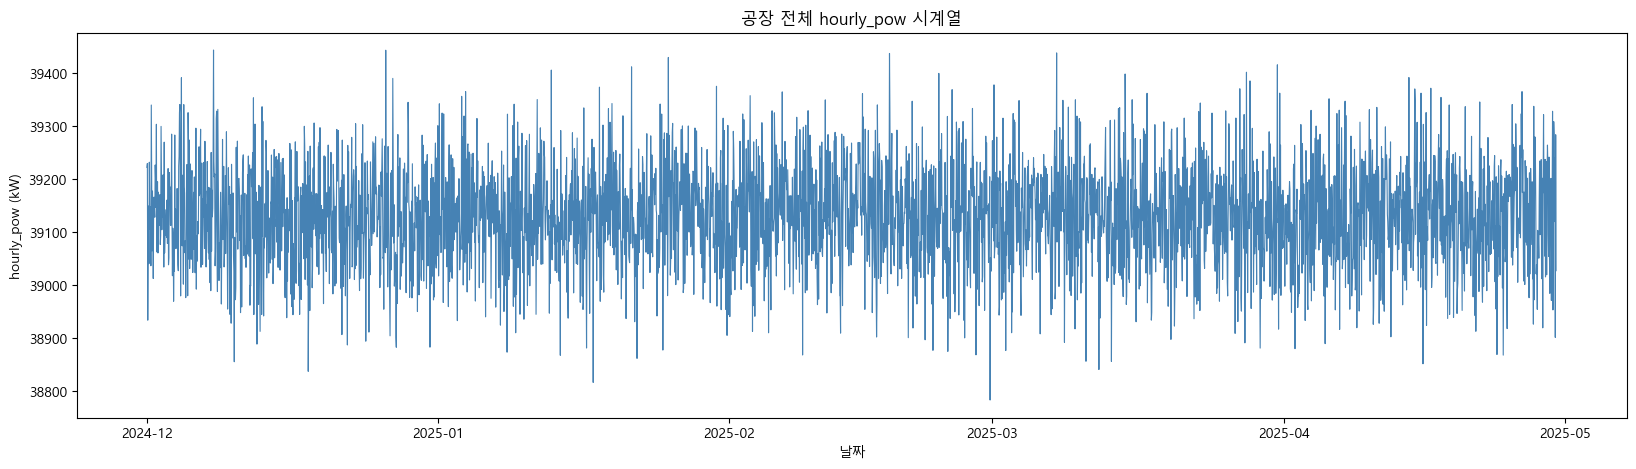

→ 인사이트: 스파이크 구간 = 이상탐지 타겟


In [18]:
# hourly_pow 시계열 전체 플롯 + 스파이크 확인
plt.figure(figsize=(20, 5))
plt.plot(hourly_pow['dt'], hourly_pow['hourly_pow'], linewidth=0.8, color='steelblue')
plt.title('공장 전체 hourly_pow 시계열')
plt.xlabel('날짜')
plt.ylabel('hourly_pow (kW)')
plt.savefig('eda_06_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ 인사이트: 스파이크 구간 = 이상탐지 타겟')

## 7. 상관관계 분석
> **목적: 어떤 피처가 activePower와 관련 있는지 확인**

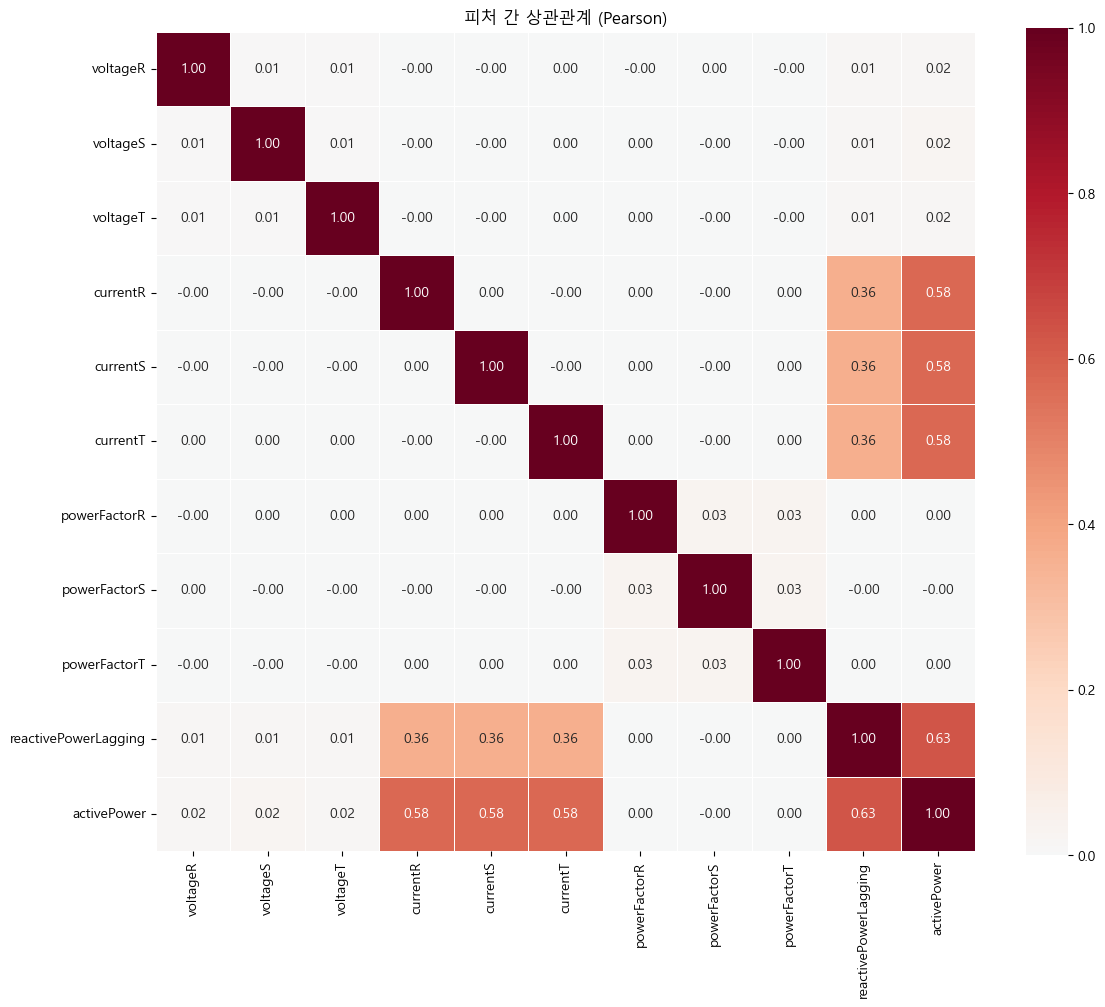

activePower와의 상관관계:
activePower             1.000000
reactivePowerLagging    0.625921
currentR                0.577052
currentS                0.577047
currentT                0.576914
voltageS                0.019255
voltageR                0.019224
voltageT                0.019118
powerFactorT            0.000267
powerFactorR            0.000243
powerFactorS           -0.000202
Name: activePower, dtype: float64
→ 인사이트: 상관 높은 피처 = 모델에 포함 / 낮은 피처 = 제외 근거


In [19]:
num_cols = ['voltageR','voltageS','voltageT','currentR','currentS','currentT',
            'powerFactorR','powerFactorS','powerFactorT','reactivePowerLagging','activePower']

corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('피처 간 상관관계 (Pearson)')
plt.tight_layout()
plt.savefig('eda_07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('activePower와의 상관관계:')
print(corr['activePower'].sort_values(ascending=False))
print('→ 인사이트: 상관 높은 피처 = 모델에 포함 / 낮은 피처 = 제외 근거')

## 8. EDA 요약
> 여기에 각 분석 결과 인사이트를 직접 채워주세요

In [20]:
print("""
=== EDA 인사이트 요약 ===

[시간 패턴]
- 피크 시간대: 특정 피크 없음 (변동폭 25kW, 전체의 0.06% 수준)
- 요일 차이: 없음 (전 요일 약 39,000kW로 균일)
- 주말/평일 차이: 없음 (24시간 풀가동)
→ 피처 포함 여부: hour_sin/cos 포함 / dow_sin/cos, is_weekend 제외

[자기상관]
- lag24 상관: 없음 (ACF에서 유의미한 피크 없음)
- lag168 상관: 없음 (ACF에서 유의미한 피크 없음)
→ 피처 포함 여부: lag 피처 효과 미미 → 모델링 단계에서 실험 후 결정

[설비별 패턴]
- 설비 간 소비량 차이: 작다 (전부 평균 3,000kW대)
- 변동성 차이: 작다 (전부 std 700kW대)
→ Bottom-Up 예측 방식 정당화: 아니오 → 전체 합산 직접 예측 방식 채택

[이상치]
- operation=0 & activePower>0 케이스: 0건 (operation 전부 1 → 변수 의미 없음)
- IQR 이상치 많은 설비: 없음 (전 설비 이상치 0건)
→ 룰 기반 이상탐지 불가 → Rolling Z-score / Isolation Forest 방식 채택

[상관관계]
- activePower와 상관 높은 피처: currentR/S/T (0.58), reactivePowerLagging (0.63)
- 제외할 피처: voltageR/S/T (0.02), powerFactorR/S/T (0.00), operation (불변)
""")


=== EDA 인사이트 요약 ===

[시간 패턴]
- 피크 시간대: 특정 피크 없음 (변동폭 25kW, 전체의 0.06% 수준)
- 요일 차이: 없음 (전 요일 약 39,000kW로 균일)
- 주말/평일 차이: 없음 (24시간 풀가동)
→ 피처 포함 여부: hour_sin/cos 포함 / dow_sin/cos, is_weekend 제외

[자기상관]
- lag24 상관: 없음 (ACF에서 유의미한 피크 없음)
- lag168 상관: 없음 (ACF에서 유의미한 피크 없음)
→ 피처 포함 여부: lag 피처 효과 미미 → 모델링 단계에서 실험 후 결정

[설비별 패턴]
- 설비 간 소비량 차이: 작다 (전부 평균 3,000kW대)
- 변동성 차이: 작다 (전부 std 700kW대)
→ Bottom-Up 예측 방식 정당화: 아니오 → 전체 합산 직접 예측 방식 채택

[이상치]
- operation=0 & activePower>0 케이스: 0건 (operation 전부 1 → 변수 의미 없음)
- IQR 이상치 많은 설비: 없음 (전 설비 이상치 0건)
→ 룰 기반 이상탐지 불가 → Rolling Z-score / Isolation Forest 방식 채택

[상관관계]
- activePower와 상관 높은 피처: currentR/S/T (0.58), reactivePowerLagging (0.63)
- 제외할 피처: voltageR/S/T (0.02), powerFactorR/S/T (0.00), operation (불변)



In [22]:
# 설비별 시간 단위 집계 (activePower + 피처 컬럼 함께)
agg_cols = {
    'activePower': 'mean',
    'currentR': 'mean',
    'currentS': 'mean', 
    'currentT': 'mean',
    'reactivePowerLagging': 'mean'
}

df_hourly_module = (
    df.groupby(['module(equipment)', pd.Grouper(key='dt', freq='1H')])
    .agg(agg_cols)
    .reset_index()
)

# 전체 설비 합산
hourly_full = (
    df_hourly_module.groupby('dt')
    .agg({
        'activePower': 'sum',        # hourly_pow
        'currentR': 'mean',          # 평균 전류
        'currentS': 'mean',
        'currentT': 'mean',
        'reactivePowerLagging': 'mean'
    })
    .reset_index()
    .rename(columns={'activePower': 'hourly_pow'})
)

# 시간 피처 추가
hourly_full['hour'] = hourly_full['dt'].dt.hour
hourly_full['hour_sin'] = np.sin(2 * np.pi * hourly_full['hour'] / 24)
hourly_full['hour_cos'] = np.cos(2 * np.pi * hourly_full['hour'] / 24)

print(hourly_full.shape)
print(hourly_full.head())

(3601, 9)
                   dt    hourly_pow   currentR   currentS   currentT  \
0 2024-12-01 00:00:00  39222.026694  17.545821  17.513784  17.572936   
1 2024-12-01 01:00:00  39229.376486  17.644235  17.504292  17.491845   
2 2024-12-01 02:00:00  38934.010514  17.471162  17.390261  17.376300   
3 2024-12-01 03:00:00  39066.889514  17.499027  17.407326  17.508141   
4 2024-12-01 04:00:00  39149.150819  17.587642  17.416513  17.529465   

   reactivePowerLagging  hour  hour_sin  hour_cos  
0            603.626283     0  0.000000  1.000000  
1            605.658051     1  0.258819  0.965926  
2            600.846719     2  0.500000  0.866025  
3            601.699624     3  0.707107  0.707107  
4            600.023209     4  0.866025  0.500000  
